In [39]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import os
import time

# Set seeds
torch.manual_seed(42)
np.random.seed(42)

print(f"Device: {device}")



Device: cpu


In [40]:


# Load splits
train_data = pd.read_pickle('dataset/train_data_final.pkl')
val_data_masked = pd.read_pickle('dataset/val_data_masked.pkl')
test_data_masked = pd.read_pickle('dataset/test_data_masked.pkl')

# Load ground truth and masks
val_ground_truth = pd.read_pickle('dataset/val_ground_truth.pkl')
test_ground_truth = pd.read_pickle('dataset/test_ground_truth.pkl')
val_mask_indicator = pd.read_pickle('dataset/val_mask_indices.pkl')
test_mask_indicator = pd.read_pickle('dataset/test_mask_indices.pkl')

print(f"\n Loaded splits:")
print(f"   Train: {train_data.shape}")
print(f"   Val: {val_data_masked.shape}")
print(f"   Test: {test_data_masked.shape}")

# Get features to impute (from ground truth columns)
features_to_impute = val_ground_truth.columns.tolist()

print(f"   Features to impute: {len(features_to_impute)}")


 Loaded splits:
   Train: (143459, 47)
   Val: (30741, 47)
   Test: (30742, 47)
   Features to impute: 37


In [41]:
features_to_impute


['ping_ms',
 'datarate',
 'jitter',
 'Latitude',
 'Longitude',
 'Altitude',
 'speed_kmh',
 'COG',
 'precipIntensity',
 'precipProbability',
 'temperature',
 'humidity',
 'windSpeed',
 'Traffic Jam Factor',
 'Traffic Distance',
 'Pos in Ref Round',
 'measurement',
 'PCell_RSRP_max',
 'PCell_RSRQ_max',
 'PCell_RSSI_max',
 'PCell_SNR_1',
 'PCell_SNR_2',
 'PCell_Downlink_Num_RBs',
 'PCell_Downlink_TB_Size',
 'PCell_Downlink_Average_MCS',
 'PCell_Uplink_Num_RBs',
 'PCell_Uplink_TB_Size',
 'PCell_Uplink_Tx_Power_(dBm)',
 'PCell_Downlink_frequency',
 'PCell_Downlink_bandwidth_MHz',
 'PCell_Uplink_bandwidth_MHz',
 'PCell_Band_Indicator',
 'PCell_freq_MHz',
 'target_datarate',
 'PCell_DL_RBs_MCS_Low',
 'PCell_DL_RBs_MCS_Mid',
 'PCell_DL_RBs_MCS_High']

In [43]:
def clip_outliers_per_feature(data, features, lower_pct=0.5, upper_pct=99.5, 
                               reference_data=None):
    """
    Clip outliers per feature based on percentiles.
    
    Args:
        data: DataFrame to clip
        features: List of features to clip
        lower_pct: Lower percentile
        upper_pct: Upper percentile
        reference_data: If provided, use this data's percentiles (for val/test)
    """
    data_clipped = data.copy()
    clipping_bounds = {}
    
    for feat in features:
        if feat not in data.columns:
            continue
        
        # Determine which data to use for percentiles
        if reference_data is not None:
            ref_col = reference_data[feat].dropna()
        else:
            ref_col = data[feat].dropna()
        
        if len(ref_col) == 0:
            continue
        
        # Calculate bounds
        lower_bound = np.percentile(ref_col, lower_pct)
        upper_bound = np.percentile(ref_col, upper_pct)
        
        clipping_bounds[feat] = (lower_bound, upper_bound)
        
        # Clip values (only non-NaN)
        mask = data_clipped[feat].notna()
        data_clipped.loc[mask, feat] = data_clipped.loc[mask, feat].clip(
            lower=lower_bound, 
            upper=upper_bound
        )
    
    return data_clipped, clipping_bounds

print("\n Clipping training data (fit bounds)...")
train_clipped, clipping_bounds = clip_outliers_per_feature(
    train_data, 
    features_to_impute
)

print(" Training data clipped")

# Show some clipping examples
print(f"\n Clipping examples (first 5 features):")
for i, feat in enumerate(list(clipping_bounds.keys())[:5]):
    lower, upper = clipping_bounds[feat]
    original_min = train_data[feat].min()
    original_max = train_data[feat].max()
    print(f"   {feat[:40]:40s}: [{original_min:>10.2e}, {original_max:>10.2e}] → [{lower:>10.2e}, {upper:>10.2e}]")

# Clip val and test using SAME bounds (from training)
print("\n Clipping val/test data (using training bounds)...")
val_clipped, _ = clip_outliers_per_feature(
    val_data_masked, 
    features_to_impute,
    reference_data=train_data
)

test_clipped, _ = clip_outliers_per_feature(
    test_data_masked, 
    features_to_impute,
    reference_data=train_data
)

print(" Val/test data clipped")

# CRITICAL: Also clip ground truth
print("\n Clipping ground truth (same bounds)...")
val_gt_clipped, _ = clip_outliers_per_feature(
    val_ground_truth,
    features_to_impute,
    reference_data=train_data
)

test_gt_clipped, _ = clip_outliers_per_feature(
    test_ground_truth,
    features_to_impute,
    reference_data=train_data
)

print(" Ground truth clipped")


 Clipping training data (fit bounds)...
 Training data clipped

 Clipping examples (first 5 features):
   ping_ms                                 : [  2.83e+00,   1.14e+01] → [  3.04e+00,   8.65e+00]
   datarate                                : [  6.75e+00,   1.93e+01] → [  1.29e+01,   1.88e+01]
   jitter                                  : [  1.60e-05,   1.01e+08] → [  4.70e-05,   3.86e-02]
   Latitude                                : [  5.25e+01,   5.25e+01] → [  5.25e+01,   5.25e+01]
   Longitude                               : [  1.32e+01,   1.34e+01] → [  1.33e+01,   1.34e+01]

 Clipping val/test data (using training bounds)...
 Val/test data clipped

 Clipping ground truth (same bounds)...
 Ground truth clipped


In [44]:

scaler = StandardScaler()

# Extract values for features to impute
train_values = train_clipped[features_to_impute].values
val_values = val_clipped[features_to_impute].values
test_values = test_clipped[features_to_impute].values

# Fit scaler on training data
scaler.fit(train_values)

# Transform all datasets
train_scaled = scaler.transform(train_values)
val_scaled = scaler.transform(val_values)
test_scaled = scaler.transform(test_values)

print(f"\n Scaled all datasets")

# Verify scale quality
print(f"\nScaled data statistics:")
print(f"   Train mean: {np.nanmean(train_scaled):.4f}")
print(f"   Train std:  {np.nanstd(train_scaled):.4f}")
print(f"   Train min:  {np.nanmin(train_scaled):.4f}")
print(f"   Train max:  {np.nanmax(train_scaled):.4f}")


 Scaled all datasets

Scaled data statistics:
   Train mean: 0.0000
   Train std:  1.0000
   Train min:  -3.9694
   Train max:  8.8233


In [45]:
# Get ALL column names
all_columns = train_data.columns.tolist()

# Separate features
continuous_features = features_to_impute  # 49 features (what we impute)


context_features = [col for col in all_columns if col not in continuous_features]




In [46]:
exclude_patterns = [
    'pcell_high_missing',
    'timestamp',
    'ts_gps','date'                                                                                 
]


In [47]:
context_features = [col for col in context_features 
                    if col not in exclude_patterns]

In [48]:
context_features

['operator',
 'device_pc1',
 'device_pc2',
 'device_pc3',
 'direction_uplink',
 'measured_qos_delay',
 'hour',
 'day_of_week']

In [49]:


print(f"\n Feature breakdown:")
print(f"   Continuous (to impute): {len(continuous_features)}")
print(f"   Context (indicators, temporal, one-hot): {len(context_features)}")
print(f"   Total input features: {len(all_columns)}")

print(f"\n Context features:")
for col in context_features:
    print(f"   {col}")



 Feature breakdown:
   Continuous (to impute): 37
   Context (indicators, temporal, one-hot): 8
   Total input features: 47

 Context features:
   operator
   device_pc1
   device_pc2
   device_pc3
   direction_uplink
   measured_qos_delay
   hour
   day_of_week


In [50]:
train_data

,timestamp,ping_ms,datarate,jitter,Latitude,Longitude,Altitude,speed_kmh,COG,precipIntensity,...,PCell_DL_RBs_MCS_Mid,PCell_DL_RBs_MCS_High,device_pc1,device_pc2,device_pc3,direction_uplink,measured_qos_delay,hour,day_of_week,date
0,2021-06-22 09:49:54+02:00,NaN,18.045260,0.000848,52.514013,13.335172,41.9,0.000000,0.0,0.0652,...,0.000000,10.305179,1,0,0,0,0,9,1,2021-06-22
1,2021-06-22 09:49:54+02:00,NaN,17.014184,0.000512,52.514008,13.335195,35.3,0.000000,259.0,0.0652,...,7.403670,10.591497,0,1,0,0,0,9,1,2021-06-22
2,2021-06-22 09:49:54+02:00,NaN,17.723526,0.000090,52.513830,13.334935,30.7,0.000000,0.0,0.0653,...,8.722091,10.536274,0,0,1,0,0,9,1,2021-06-22
3,2021-06-22 09:49:54+02:00,7.242082,18.071123,0.000207,52.513848,13.334832,32.3,0.000000,265.9,0.0653,...,4.262680,10.322329,0,0,0,0,0,9,1,2021-06-22
4,2021-06-22 09:49:55+02:00,NaN,16.850464,0.002268,52.514005,13.335195,35.4,0.000000,259.0,0.0652,...,7.603399,10.172827,0,1,0,0,0,9,1,2021-06-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143454,2021-06-23 15:51:36+02:00,3.254243,12.884109,0.002815,52.513112,13.329863,35.9,0.000000,84.0,0.0646,...,1.609438,2.302585,0,0,1,1,1,15,2,2021-06-23
143455,2021-06-23 15:51:36+02:00,3.781914,12.884109,0.002089,52.513095,13.329760,34.5,0.000000,84.3,0.0646,...,3.496508,2.197225,1,0,0,1,1,15,2,2021-06-23
143456,2021-06-23 15:51:36+02:00,3.254243,12.884109,0.003071,52.513088,13.329952,32.5,0.000000,83.6,0.0646,...,0.000000,0.000000,0,1,0,1,1,15,2,2021-06-23
143457,2021-06-23 15:51:36+02:00,3.342155,12.906694,0.001906,52.513153,13.331378,28.6,2.463138,83.3,0.0646,...,0.000000,3.401197,0,0,0,1,1,15,2,2021-06-23


In [51]:
from sklearn.preprocessing import MinMaxScaler

# Get context features (these are already in good shape: 0/1 or small integers)
train_context = train_data[context_features].values  # Fill any NaN with 0
val_context = val_data_masked[context_features].values
test_context = test_data_masked[context_features].values


# Scale context features
context_scaler = MinMaxScaler()

# Fit on train context
context_scaler.fit(train_context)

# Transform all
train_context_scaled = context_scaler.transform(train_context)
val_context_scaled = context_scaler.transform(val_context)
test_context_scaled = context_scaler.transform(test_context)




In [53]:


# Combine: [scaled continuous | raw context]
train_full = np.hstack([train_scaled,train_context])
val_full = np.hstack([val_scaled,val_context])
test_full = np.hstack([test_scaled,test_context])

print(f"\n Combined features:")
print(f"   Train: {train_full.shape}")
print(f"   Val: {val_full.shape}")
print(f"   Test: {test_full.shape}")

# Verify
print(f"\n Full input statistics:")
print(f"   Mean: {np.nanmean(train_full):.4f}")
print(f"   Std: {np.nanstd(train_full):.4f}")
print(f"   Min: {np.nanmin(train_full):.4f}")
print(f"   Max: {np.nanmax(train_full):.4f}")


 Combined features:
   Train: (143459, 45)
   Val: (30741, 45)
   Test: (30742, 45)

 Full input statistics:
   Mean: 0.3831
   Std: 2.2032
   Min: -3.9694
   Max: 18.0000


In [54]:


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import time

# Seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n Device: {device}")


 Device: cpu


In [55]:

print(f"\n Using existing preprocessed data:")
print(f"   Train: {train_full.shape}")
print(f"   Val: {val_full.shape}")
print(f"   Test: {test_full.shape}")


 Using existing preprocessed data:
   Train: (143459, 45)
   Val: (30741, 45)
   Test: (30742, 45)


In [56]:
class SimpleDenoisingDataset(Dataset):
    """Dataset with continuous and context features"""
    
    def __init__(self, full_data, continuous_data, context_data, noise_ratio=0.2, training=True):
        """
        Args:
            full_data: All features combined (numpy array) - not used directly anymore
            continuous_data: Continuous features (for input & target)
            context_data: Context features (binary/categorical)
            noise_ratio: Artificial noise for training
            training: Whether to add noise
        """
        self.continuous_data = continuous_data
        self.context_data = context_data
        self.noise_ratio = noise_ratio
        self.training = training
        self.n_continuous = continuous_data.shape[1]
        self.n_context = context_data.shape[1]
    
    def __len__(self):
        return len(self.continuous_data)
    
    def __getitem__(self, idx):
        continuous_row = self.continuous_data[idx].copy()
        context_row = self.context_data[idx].copy()
        
        # Mask for continuous features (1=observed, 0=missing)
        mask_observed = ~np.isnan(continuous_row)
        
        # Fill NaN in continuous with 0
        continuous_filled = np.nan_to_num(continuous_row, nan=0.0)
        
        # Fill NaN in context with 0
        context_filled = np.nan_to_num(context_row, nan=0.0)
        
        if self.training and mask_observed.sum() > 0:
            continuous_input = continuous_filled.copy()
            
            # Mask some observed continuous values
            observed_indices = np.where(mask_observed)[0]
            n_to_mask = max(1, int(len(observed_indices) * self.noise_ratio))
            if n_to_mask < len(observed_indices):
                mask_indices = np.random.choice(
                    observed_indices, size=n_to_mask, replace=False
                )
                continuous_input[mask_indices] = 0.0
            
            # Combine: [noisy continuous | clean context]
            full_input = np.concatenate([continuous_input, context_filled])
        else:
            # Validation/test: no noise
            full_input = np.concatenate([continuous_filled, context_filled])
        
        return (torch.FloatTensor(full_input),                        # Input: continuous + context
                torch.FloatTensor(continuous_filled),                  # Target: continuous only
                torch.FloatTensor(mask_observed.astype(np.float32)))   # Mask: continuous only


# Create datasets
NOISE_RATIO = 0.2
BATCH_SIZE = 512

train_dataset = SimpleDenoisingDataset(train_full, train_scaled, train_context, noise_ratio=NOISE_RATIO, training=True)
val_dataset = SimpleDenoisingDataset(val_full, val_scaled, val_context, noise_ratio=0.0, training=False)
test_dataset = SimpleDenoisingDataset(test_full, test_scaled, test_context, noise_ratio=0.0, training=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n Datasets created:")
print(f"   Train: {len(train_dataset):,} samples (20% noise)")
print(f"   Val: {len(val_dataset):,} samples")
print(f"   Test: {len(test_dataset):,} samples")
print(f"   Input features: {train_dataset.n_continuous} continuous + {train_dataset.n_context} context")
print(f"   Batch size: {BATCH_SIZE}")


 Datasets created:
   Train: 143,459 samples (20% noise)
   Val: 30,741 samples
   Test: 30,742 samples
   Input features: 37 continuous + 8 context
   Batch size: 512


In [60]:

class SimpleDenoisingAutoencoder(nn.Module):
    """Simple autoencoder: 46 → 128 → 64 → 32 → 64 → 128 → 46"""
    def __init__(self, input_dim, output_dim, hidden_dims=[128, 64, 32]):
        super(SimpleDenoisingAutoencoder, self).__init__()
        
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_dim = hidden_dim
        
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Decoder
        decoder_layers = []
        reversed_dims = list(reversed(hidden_dims[:-1])) + [output_dim]
        
        for i, hidden_dim in enumerate(reversed_dims):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            
            if i < len(reversed_dims) - 1:
                decoder_layers.extend([
                    nn.ReLU(),
                    nn.Dropout(0.2)
                ])
            
            prev_dim = hidden_dim
        
        self.decoder = nn.Sequential(*decoder_layers)
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

INPUT_DIM = 45
HIDDEN_DIMS = [128, 64, 32]
output_dim= 37

model = SimpleDenoisingAutoencoder(INPUT_DIM,output_dim, HIDDEN_DIMS).to(device)

print(f"\n Model created:")
print(f"   Architecture: {INPUT_DIM} → {' → '.join(map(str, HIDDEN_DIMS))} → {' → '.join(map(str, reversed(HIDDEN_DIMS[:-1])))} → {output_dim}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")


 Model created:
   Architecture: 45 → 128 → 64 → 32 → 64 → 128 → 37
   Parameters: 31,429


In [61]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

NUM_EPOCHS = 40
EARLY_STOP_PATIENCE = 10

print(f"\n  Configuration:")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Learning rate: 0.001")
print(f"   Optimizer: Adam")
print(f"   Early stopping: {EARLY_STOP_PATIENCE}")


  Configuration:
   Epochs: 40
   Learning rate: 0.001
   Optimizer: Adam
   Early stopping: 10


In [63]:

history = {'train_loss': [], 'val_loss': [], 'epoch_times': []}
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\n Starting training...")
print(f"{'Epoch':<8s} {'Train Loss':<15s} {'Val Loss':<15s} {'Time':<10s} {'Status'}")
print("─"*70)

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    # Training
    model.train()
    train_losses = []
    
    for input_batch, target_batch, mask_batch in train_loader:
        input_batch = input_batch.to(device)
        target_batch = target_batch.to(device)
        mask_batch = mask_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(input_batch)
        
        # Loss only on observed values
        loss = criterion(outputs * mask_batch, target_batch * mask_batch)
        
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
    
    avg_train_loss = np.mean(train_losses)
    
    # Validation
    model.eval()
    val_losses = []
    
    with torch.no_grad():
        for input_batch, target_batch, mask_batch in val_loader:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            mask_batch = mask_batch.to(device)
            
            outputs = model(input_batch)
            loss = criterion(outputs * mask_batch, target_batch * mask_batch)
            
            val_losses.append(loss.item())
    
    avg_val_loss = np.mean(val_losses)
    
    # Record
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['epoch_times'].append(epoch_time)
    
    scheduler.step(avg_val_loss)
    
    # Early stopping
    status = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        status = " Best!"
    else:
        patience_counter += 1
        status = f"({patience_counter}/{EARLY_STOP_PATIENCE})"
    
    print(f"{epoch+1:<8d} {avg_train_loss:<15.6f} {avg_val_loss:<15.6f} {epoch_time:<10.2f}s {status}")
    
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n  Early stopping at epoch {epoch+1}")
        break

# Restore best
model.load_state_dict(best_model_state)

print(f"\n Training complete!")
print(f"   Epochs: {len(history['train_loss'])}")
print(f"   Best val loss: {best_val_loss:.6f}")
print(f"   Total time: {sum(history['epoch_times']):.1f}s")



 Starting training...
Epoch    Train Loss      Val Loss        Time       Status
──────────────────────────────────────────────────────────────────────
1        0.377875        0.348598        27.25     s  Best!
2        0.348083        0.312009        29.02     s  Best!
3        0.328424        0.296580        25.02     s  Best!
4        0.313698        0.286511        24.81     s  Best!
5        0.300378        0.273772        22.57     s  Best!
6        0.291410        0.268699        24.83     s  Best!
7        0.284295        0.267087        25.20     s  Best!
8        0.278354        0.255755        23.72     s  Best!
9        0.273988        0.257348        24.09     s (1/10)
10       0.269622        0.247799        22.50     s  Best!
11       0.266007        0.248446        23.70     s (1/10)
12       0.262276        0.245518        23.10     s  Best!
13       0.258828        0.240255        23.25     s  Best!
14       0.256572        0.241132        24.07     s (1/10)
15     

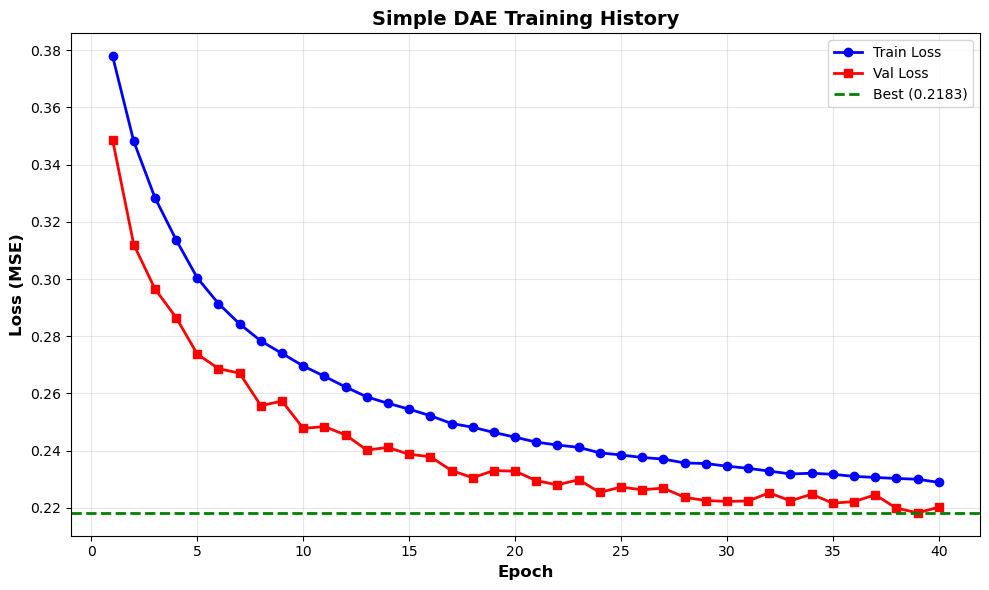

 SIMPLE DAE TRAINING COMPLETE

  RESULTS:
   Best validation loss: 0.218280
   Epochs: 40
   Total time: 956.1s

 NEXT: Evaluate on test set!



In [64]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

epochs = range(1, len(history['train_loss']) + 1)

ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2, marker='o')
ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2, marker='s')
ax.axhline(y=best_val_loss, color='g', linestyle='--', linewidth=2, label=f'Best ({best_val_loss:.4f})')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
ax.set_title('Simple DAE Training History', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()


print(" SIMPLE DAE TRAINING COMPLETE")


print(f"""
  RESULTS:
   Best validation loss: {best_val_loss:.6f}
   Epochs: {len(history['train_loss'])}
   Total time: {sum(history['epoch_times']):.1f}s

 NEXT: Evaluate on test set!
""")

In [65]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

model.eval()
all_predictions = []

print("\n Generating predictions on test set...")

with torch.no_grad():
    for input_batch, _, _ in test_loader:
        input_batch = input_batch.to(device)
        outputs = model(input_batch)
        all_predictions.append(outputs.cpu().numpy())

predictions_scaled = np.vstack(all_predictions)

print(f" Predictions generated: {predictions_scaled.shape}")
print(f"   In scaled space (mean≈0, std≈1)")


 Generating predictions on test set...
 Predictions generated: (30742, 37)
   In scaled space (mean≈0, std≈1)


In [66]:

# Inverse transform predictions
predictions_original = scaler.inverse_transform(predictions_scaled)

print(f" Predictions transformed to original (clipped) scale")
print(f"   Shape: {predictions_original.shape}")
print(f"   Range: [{predictions_original.min():.2f}, {predictions_original.max():.2f}]")

# Create DataFrame with predictions
test_imputed = test_data_masked.copy()
test_imputed[continuous_features] = predictions_original

print(f" Created imputed test dataframe")

 Predictions transformed to original (clipped) scale
   Shape: (30742, 37)
   Range: [-117.11, 2967.38]
 Created imputed test dataframe


In [67]:

results = []
all_errors_sq = []
all_errors_abs = []

for col in continuous_features:
    # Get mask: which positions were artificially masked?
    mask = test_mask_indicator[col]
    
    if mask.sum() == 0:
        continue  # No masked values for this feature
    
    # Get ground truth at masked positions (CLIPPED!)
    true_vals = test_gt_clipped.loc[mask, col].dropna()
    
    if len(true_vals) == 0:
        continue
    
    # Get predictions at same positions
    pred_vals = test_imputed.loc[true_vals.index, col]
    
    # Calculate errors
    errors = true_vals - pred_vals
    errors_sq = errors ** 2
    errors_abs = errors.abs()
    
    rmse = np.sqrt(errors_sq.mean())
    mae = errors_abs.mean()
    
    # Store results
    results.append({
        'feature': col,
        'n_masked': len(true_vals),
        'RMSE': rmse,
        'MAE': mae
    })
    
    # Collect for overall metrics
    all_errors_sq.extend(errors_sq.values)
    all_errors_abs.extend(errors_abs.values)

# Calculate overall metrics
overall_rmse = np.sqrt(np.mean(all_errors_sq))
overall_mae = np.mean(all_errors_abs)

print(f"\n OVERALL PERFORMANCE:")
print(f"   Overall RMSE: {overall_rmse:.4f}")
print(f"   Overall MAE:  {overall_mae:.4f}")
print(f"   Features evaluated: {len(results)}")
print(f"   Total evaluation points: {len(all_errors_sq):,}")


 OVERALL PERFORMANCE:
   Overall RMSE: 59.1702
   Overall MAE:  9.5618
   Features evaluated: 37
   Total evaluation points: 167,377


In [69]:
results_df = pd.DataFrame(results)
results_sorted = results_df.sort_values('RMSE')

print(f"\n TOP BEST FEATURES (Lowest RMSE):")
print(f"{'Feature':<50s} {'N Masked':>10s} {'RMSE':>12s} {'MAE':>12s}")
print("─"*90)
for idx, row in results_sorted.iterrows():
    print(f"{row['feature']:<50s} {row['n_masked']:>10.0f} {row['RMSE']:>12.4f} {row['MAE']:>12.4f}")




 TOP BEST FEATURES (Lowest RMSE):
Feature                                              N Masked         RMSE          MAE
──────────────────────────────────────────────────────────────────────────────────────────
jitter                                                   4555       0.0028       0.0012
Latitude                                                 4611       0.0049       0.0034
Longitude                                                4611       0.0207       0.0158
humidity                                                 4611       0.0385       0.0282
precipProbability                                        4611       0.0688       0.0646
precipIntensity                                          4611       0.0969       0.0919
PCell_Band_Indicator                                     4411       0.4942       0.2523
target_datarate                                          4611       0.6399       0.3393
datarate                                                 4555       0.6671       0

In [71]:


import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_predictions = []

with torch.no_grad():
    for input_batch, _, _ in test_loader:
        input_batch = input_batch.to(device)
        outputs = model(input_batch)
        all_predictions.append(outputs.cpu().numpy())

predictions_scaled = np.vstack(all_predictions)
predictions_original = scaler.inverse_transform(predictions_scaled)

test_imputed = test_data_masked.copy()
test_imputed[continuous_features] = predictions_original

print(f" Predictions generated: {predictions_original.shape}")

 Predictions generated: (30742, 37)


In [72]:

results = []
all_errors = []
all_errors_abs = []

for col in continuous_features:
    mask = test_mask_indicator[col]
    
    if mask.sum() == 0:
        continue
    
    # Get ground truth (CLIPPED)
    true_vals = test_gt_clipped.loc[mask, col].dropna()
    
    if len(true_vals) == 0:
        continue
    
    pred_vals = test_imputed.loc[true_vals.index, col]
    
    # Calculate errors
    errors = true_vals - pred_vals
    errors_abs = errors.abs()
    errors_sq = errors ** 2
    
    # Basic metrics
    rmse = np.sqrt(errors_sq.mean())
    mae = errors_abs.mean()
    median_ae = errors_abs.median()
    
    # Normalized metrics (by range)
    feature_range = train_data[col].max() - train_data[col].min()
    nrmse = rmse / (feature_range + 1e-8)
    
    # Normalized metrics (by std)
    feature_std = train_data[col].std()
    nrmse_std = rmse / (feature_std + 1e-8)
    
    # Error distribution
    percentile_25 = errors_abs.quantile(0.25)
    percentile_75 = errors_abs.quantile(0.75)
    percentile_95 = errors_abs.quantile(0.95)
    
    # Store results
    results.append({
        'feature': col,
        'n_masked': len(true_vals),
        'RMSE': rmse,
        'MAE': mae,
        'MedianAE': median_ae,
        'NRMSE': nrmse,
        'NRMSE_std': nrmse_std,
        'feature_range': feature_range,
        'feature_std': feature_std,
        'error_p25': percentile_25,
        'error_p75': percentile_75,
        'error_p95': percentile_95
    })
    
    # Collect for overall metrics
    all_errors.extend(errors.values)
    all_errors_abs.extend(errors_abs.values)

results_df = pd.DataFrame(results)

In [73]:

# Calculate overall metrics
overall_rmse = np.sqrt(np.mean([e**2 for e in all_errors]))
overall_mae = np.mean(all_errors_abs)
overall_median_ae = np.median(all_errors_abs)
overall_nrmse = results_df['NRMSE'].mean()
overall_nrmse_std = results_df['NRMSE_std'].mean()

print(f"\n OVERALL METRICS:")
print(f"   RMSE:          {overall_rmse:,.2f}")
print(f"   MAE:           {overall_mae:,.2f}")
print(f"   Median AE:     {overall_median_ae:,.2f} ")
print(f"   NRMSE (range): {overall_nrmse:.4f} ")
print(f"   NRMSE (std):   {overall_nrmse_std:.4f}")
print(f"   Features:      {len(results)}")
print(f"   Eval points:   {len(all_errors):,}")

# Interpretation
print(f"\n INTERPRETATION:")
if overall_nrmse < 0.1:
    print(f"   EXCELLENT: NRMSE < 0.1 (errors < 10% of feature range)")
elif overall_nrmse < 0.3:
    print(f"   GOOD: NRMSE 0.1-0.3 (errors 10-30% of feature range)")
elif overall_nrmse < 0.5:
    print(f"    MODERATE: NRMSE 0.3-0.5 (errors 30-50% of feature range)")
else:
    print(f"   POOR: NRMSE > 0.5 (errors > 50% of feature range)")



 OVERALL METRICS:
   RMSE:          59.17
   MAE:           9.56
   Median AE:     0.66 
   NRMSE (range): 0.1742 
   NRMSE (std):   0.7697
   Features:      37
   Eval points:   167,377

 INTERPRETATION:
   GOOD: NRMSE 0.1-0.3 (errors 10-30% of feature range)


In [75]:

# Categorize by NRMSE
excellent = results_df[results_df['NRMSE'] < 0.1]
good = results_df[(results_df['NRMSE'] >= 0.1) & (results_df['NRMSE'] < 0.3)]
moderate = results_df[(results_df['NRMSE'] >= 0.3) & (results_df['NRMSE'] < 0.5)]
poor = results_df[results_df['NRMSE'] >= 0.5]

print(f"\n PERFORMANCE CATEGORIES (by NRMSE):")
print(f"   Excellent (< 0.1):  {len(excellent)} features ({len(excellent)/len(results)*100:.1f}%)")
print(f"   Good (0.1-0.3):     {len(good)} features ({len(good)/len(results)*100:.1f}%)")
print(f"   Moderate (0.3-0.5): {len(moderate)} features ({len(moderate)/len(results)*100:.1f}%)")
print(f"   Poor (> 0.5):       {len(poor)} features ({len(poor)/len(results)*100:.1f}%)")

if len(excellent) > 0:
    print(f"\n EXCELLENT FEATURES (NRMSE < 0.1):")
    for idx, row in excellent.head(10).iterrows():
        print(f"   {row['feature']:<40s} NRMSE: {row['NRMSE']:.4f}, MedianAE: {row['MedianAE']:.4f}")

if len(poor) > 0:
    print(f"\n POOR FEATURES (NRMSE > 0.5):")
    for idx, row in poor.iterrows():
        print(f"   {row['feature']:<40s} NRMSE: {row['NRMSE']:.4f}, RMSE: {row['RMSE']:,.0f}")


 PERFORMANCE CATEGORIES (by NRMSE):
   Excellent (< 0.1):  16 features (43.2%)
   Good (0.1-0.3):     16 features (43.2%)
   Moderate (0.3-0.5): 1 features (2.7%)
   Poor (> 0.5):       4 features (10.8%)

 EXCELLENT FEATURES (NRMSE < 0.1):
   ping_ms                                  NRMSE: 0.0825, MedianAE: 0.4452
   datarate                                 NRMSE: 0.0531, MedianAE: 0.4597
   jitter                                   NRMSE: 0.0000, MedianAE: 0.0007
   Altitude                                 NRMSE: 0.0468, MedianAE: 3.5519
   Pos in Ref Round                         NRMSE: 0.0698, MedianAE: 0.1834
   PCell_RSRP_max                           NRMSE: 0.0592, MedianAE: 4.9447
   PCell_RSRQ_max                           NRMSE: 0.0679, MedianAE: 1.5434
   PCell_SNR_1                              NRMSE: 0.0955, MedianAE: 3.1688
   PCell_SNR_2                              NRMSE: 0.0848, MedianAE: 2.6966
   PCell_Uplink_TB_Size                     NRMSE: 0.0876, MedianAE: 0.716

In [76]:

# Features with extreme RMSE
extreme_rmse = results_df.nlargest(5, 'RMSE')

print(f"\n TOP 5 FEATURES DESTROYING OVERALL RMSE:")
print(f"{'Feature':<40s} {'RMSE':>15s} {'NRMSE':>10s} {'% of Total RMSE²':>18s}")


total_rmse_squared = sum([e**2 for e in all_errors])

for idx, row in extreme_rmse.iterrows():
    # Get errors for this feature
    mask = test_mask_indicator[row['feature']]
    true_vals = test_gt_clipped.loc[mask, row['feature']].dropna()
    pred_vals = test_imputed.loc[true_vals.index, row['feature']]
    feature_errors_sq = ((true_vals - pred_vals) ** 2).sum()
    
    contribution_pct = (feature_errors_sq / total_rmse_squared) * 100
    
    print(f"{row['feature']:<40s} {row['RMSE']:>15,.0f} {row['NRMSE']:>10.4f} {contribution_pct:>17.1f}%")



 TOP 5 FEATURES DESTROYING OVERALL RMSE:
Feature                                             RMSE      NRMSE   % of Total RMSE²
PCell_Downlink_frequency                             351     0.0376              92.5%
PCell_freq_MHz                                        73     0.0387               4.2%
COG                                                   62     0.1713               3.0%
PCell_RSSI_max                                         9     0.1210               0.1%
PCell_RSRP_max                                         7     0.0592               0.0%


In [77]:

# Define problem features (NRMSE > 0.5 or top 5 RMSE)
problem_features = set(poor['feature'].tolist() + extreme_rmse['feature'].tolist())

print(f"\n PROBLEM FEATURES ({len(problem_features)}):")
for feat in problem_features:
    print(f"  • {feat}")

# Calculate RMSE without problem features
good_features_errors = []
for err, col_idx in zip(all_errors, [continuous_features.index(f) for f in continuous_features for _ in range(int(results_df[results_df['feature']==f]['n_masked'].values[0] if f in results_df['feature'].values else 0))]):
    feat = continuous_features[col_idx] if col_idx < len(continuous_features) else None
    if feat and feat not in problem_features:
        good_features_errors.append(err)

# Simpler approach: recalculate
good_features_results = results_df[~results_df['feature'].isin(problem_features)]
problem_features_results = results_df[results_df['feature'].isin(problem_features)]

print(f"\n COMPARISON:")
print(f"{'Metric':<30s} {'All Features':>20s} {'Good Features Only':>25s}")
print("─"*80)
print(f"{'Overall RMSE':<30s} {overall_rmse:>20,.2f} {good_features_results['RMSE'].mean():>25,.2f}")
print(f"{'Overall MAE':<30s} {overall_mae:>20,.2f} {good_features_results['MAE'].mean():>25,.2f}")
print(f"{'Overall NRMSE':<30s} {overall_nrmse:>20.4f} {good_features_results['NRMSE'].mean():>25.4f}")
print(f"{'Number of features':<30s} {len(results):>20d} {len(good_features_results):>25d}")


 PROBLEM FEATURES (9):
  • PCell_RSSI_max
  • precipIntensity
  • PCell_RSRP_max
  • PCell_freq_MHz
  • COG
  • windSpeed
  • PCell_Downlink_frequency
  • precipProbability
  • measurement

 COMPARISON:
Metric                                 All Features        Good Features Only
────────────────────────────────────────────────────────────────────────────────
Overall RMSE                                  59.17                      1.66
Overall MAE                                    9.56                      1.19
Overall NRMSE                                0.1742                    0.1253
Number of features                               37                        28


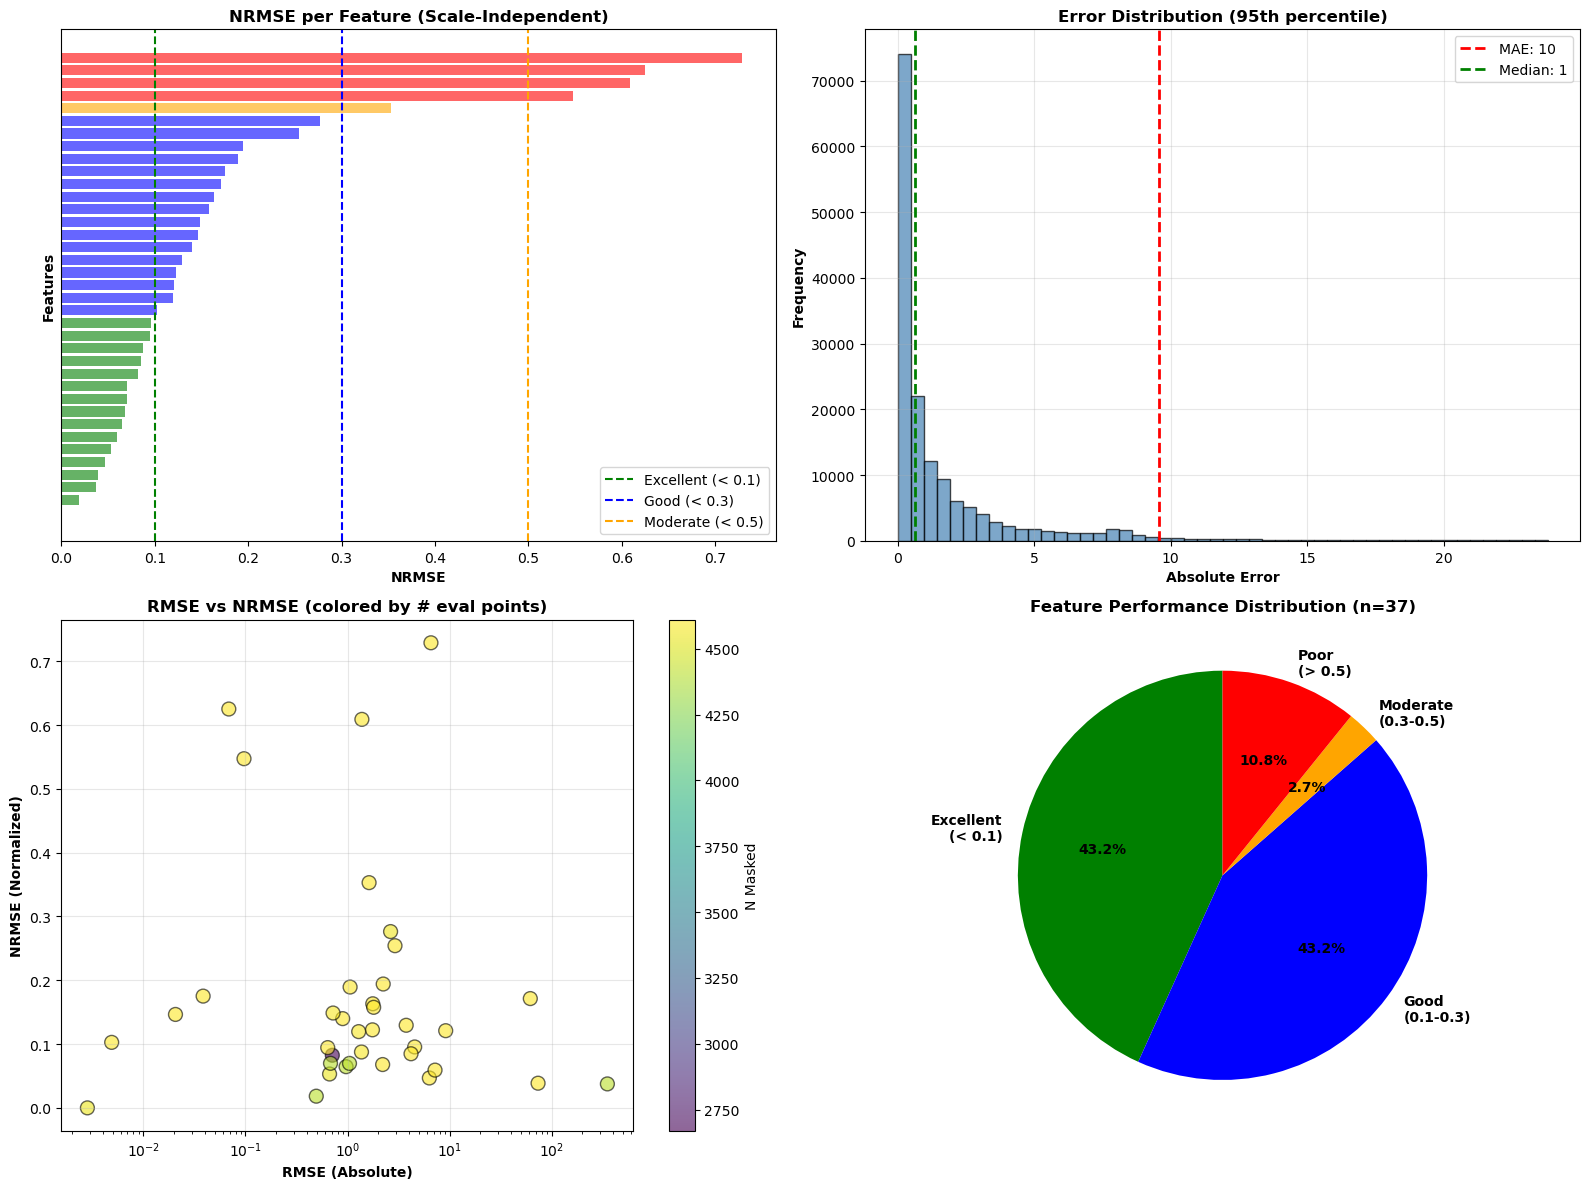

In [78]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: NRMSE distribution
ax1 = axes[0, 0]
results_sorted = results_df.sort_values('NRMSE')
colors = ['green' if x < 0.1 else 'blue' if x < 0.3 else 'orange' if x < 0.5 else 'red' 
          for x in results_sorted['NRMSE']]
ax1.barh(range(len(results_sorted)), results_sorted['NRMSE'], color=colors, alpha=0.6)
ax1.axvline(x=0.1, color='green', linestyle='--', label='Excellent (< 0.1)')
ax1.axvline(x=0.3, color='blue', linestyle='--', label='Good (< 0.3)')
ax1.axvline(x=0.5, color='orange', linestyle='--', label='Moderate (< 0.5)')
ax1.set_xlabel('NRMSE', fontweight='bold')
ax1.set_ylabel('Features', fontweight='bold')
ax1.set_title('NRMSE per Feature (Scale-Independent)', fontweight='bold', fontsize=12)
ax1.legend()
ax1.set_yticks([])

# Plot 2: Error distribution
ax2 = axes[0, 1]
errors_abs_array = np.array(all_errors_abs)
ax2.hist(errors_abs_array[errors_abs_array < np.percentile(errors_abs_array, 95)], 
         bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=overall_mae, color='red', linestyle='--', linewidth=2, label=f'MAE: {overall_mae:,.0f}')
ax2.axvline(x=overall_median_ae, color='green', linestyle='--', linewidth=2, label=f'Median: {overall_median_ae:,.0f}')
ax2.set_xlabel('Absolute Error', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.set_title('Error Distribution (95th percentile)', fontweight='bold', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: RMSE vs NRMSE
ax3 = axes[1, 0]
scatter = ax3.scatter(results_df['RMSE'], results_df['NRMSE'], 
                     c=results_df['n_masked'], cmap='viridis', 
                     alpha=0.6, s=100, edgecolors='black')
ax3.set_xlabel('RMSE (Absolute)', fontweight='bold')
ax3.set_ylabel('NRMSE (Normalized)', fontweight='bold')
ax3.set_title('RMSE vs NRMSE (colored by # eval points)', fontweight='bold', fontsize=12)
ax3.set_xscale('log')
plt.colorbar(scatter, ax=ax3, label='N Masked')
ax3.grid(alpha=0.3)

# Plot 4: Feature categories pie chart
ax4 = axes[1, 1]
categories = ['Excellent\n(< 0.1)', 'Good\n(0.1-0.3)', 'Moderate\n(0.3-0.5)', 'Poor\n(> 0.5)']
sizes = [len(excellent), len(good), len(moderate), len(poor)]
colors_pie = ['green', 'blue', 'orange', 'red']
ax4.pie(sizes, labels=categories, colors=colors_pie, autopct='%1.1f%%',
        startangle=90, textprops={'fontweight': 'bold'})
ax4.set_title(f'Feature Performance Distribution (n={len(results)})', 
             fontweight='bold', fontsize=12)

plt.tight_layout()

plt.show()



In [79]:
import os
os.makedirs('research/models', exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'clipping_bounds': clipping_bounds,
    'history': history,
    'hyperparameters': {
        'input_dim': INPUT_DIM,
        'hidden_dims': HIDDEN_DIMS,
        'batch_size': BATCH_SIZE,
        'noise_ratio': NOISE_RATIO,
        'best_val_loss': best_val_loss
    },
    'features': continuous_features
}, 'research/models/simple_dae_model_all_feat.pt')

print(" Saved: models/simple_dae_model_all_feat.pt")

# Save history
history_df = pd.DataFrame({
    'epoch': range(1, len(history['train_loss']) + 1),
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'epoch_time': history['epoch_times']
})
history_df.to_csv('research/models/simple_dae_history_all_feat.csv', index=False)
print(" Saved: models/simple_dae_history_all_feat.csv")


 Saved: models/simple_dae_model_all_feat.pt
 Saved: models/simple_dae_history_all_feat.csv
